In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input,Activation, MaxPooling1D
from tensorflow.keras.layers import Convolution1D as Conv1D
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from tensorflow.keras import layers
import numpy
import pandas as pd
import os
from sklearn import model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [9]:
%load_ext Cython

In [10]:
%%cython
import numpy as np
np.get_include() 
cimport cython
cimport numpy as np

cdef dict bases={ 'A':<int>0, 'C':<int>1, 'G':<int>2, 'T':<int>3 } 

@cython.boundscheck(False)
def one_hot_DNA( str string ):
    cdef np.ndarray[np.float32_t, ndim=2] res = np.zeros( (4,len(string)), dtype=np.float32 )
    cdef int j
    for j in range(len(string)):
        if string[j] in bases: # bases can be 'N' signifying missing: this corresponds to all 0 in the encoding
            res[ bases[ string[j] ], j ]=float(1.0)
    return(res)

def encode_DNA(seqs):
    x = np.zeros((len(seqs),4,len(seqs[0])),np.int8)
    # random sequence 
    for i in range(len(seqs)):
        x[i,:,:] = one_hot_DNA(seqs[i])
    return x

In [5]:
def fasta_to_dic(fasta_dir):
    from Bio import SeqIO
    positive = {}
    for record in SeqIO.parse(fasta_dir, "fasta"):
            positive[record.id]=[str(record.seq),str(record.seq.complement())]
    return positive

In [12]:
positive = fasta_to_dic("../expand_peaks_1000bp_fasta_hg38/THP1_macrophages.idr.optimal_peak.expand_1000bp_hg38.fasta")
negative = fasta_to_dic('../background_negatives_1000bp_hg38/THP1_macrophages.GCmatched.background_1000bp_hg38.fasta')

In [13]:
negative_seqs = list(negative.values())
positive_seqs = list(positive.values())

import random

random.shuffle(negative_seqs)
random.shuffle(positive_seqs)
y=[0]*len(negative_seqs)+[1]*len(positive_seqs)

In [12]:
def make_test(proportion,negative_seqs,positive_seqs):
    x_test = []
    x_neg=negative_seqs[0:int(len(negative_seqs)*proportion)]
    x_pos=positive_seqs[0:int(len(positive_seqs)*proportion)]
    x_neg.append(x_pos)
    for i in x_neg:
        x_test.append(str(i))
        
    
    return x_test

In [18]:
X_train, X_test, y_train, y_test=model_selection.train_test_split(negative_seqs+positive_seqs,y,test_size=0.05, random_state=10451)

In [19]:
def negative_proportion(y_train):    
    n=0
    for i in range(len(y_train)):

        if y_train[i]==0:
            n+=1
    print(n)
    print(n/len(y_train))
negative_proportion(y_train)

139348
0.4959109447176808


In [20]:
df = pd.DataFrame(X_train,columns=["forward","reverse"])
df["y"]=y_train

In [21]:
X_train_f = encode_DNA(df["forward"])
X_train_r = encode_DNA(df["reverse"])
#X_train_f = X_train_f.reshape(X_train_f.shape[0],1000,4)
#X_train_r = X_train_r.reshape(X_train_r.shape[0],1000,4)


X_train_f=X_train_f.swapaxes(1, 2)
X_train_r=X_train_r.swapaxes(1, 2)

In [25]:

from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
#from keras.layers import Dense, Dropout, Flatten, Input,Activation,MaxPooling2D, GRU,LSTM, MaxPooling1D
#from keras.layers import Convolution2D as Conv2D
#from keras.layers import Convolution1D as Conv1D
import numpy
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


#Process input as tensor
Dinput = Input(shape=(1000,4))
Tinput = Input(shape=(1000,4))


#forward sequences
encode_d= Conv1D(padding="valid",strides=1,activation="relu",kernel_size=10,filters=100,use_bias=True)(Dinput)
encode_d = MaxPooling1D()(encode_d)
encode_d = Dropout(0.2)(encode_d)
encode_d= Conv1D(padding="valid",strides=1,activation="relu",kernel_size=3,filters=100,use_bias=True)(encode_d)   
encode_d = MaxPooling1D()(encode_d)
encode_d = Dropout(0.2)(encode_d)
encode_d=Flatten()(encode_d)
#FC_DNA = Dense(100, activation='relu')(encode_d)

#reverse complementry subnetwork
encode_tt = Conv1D(padding="valid",strides=1,activation="relu",kernel_size=10,filters=100,use_bias=True)(Tinput)
encode_tt = MaxPooling1D()(encode_tt)
encode_tt = Dropout(0.2)(encode_tt)
encode_tt = Conv1D(padding="valid",strides=1,activation="relu",kernel_size=3,filters=100,use_bias=True)(encode_tt)
encode_tt = MaxPooling1D()(encode_tt)
encode_tt = Dropout(0.2)(encode_tt)
encode_tt=Flatten()(encode_tt)
#FC_AA = Dense(100, activation='relu')(encode_tt)

#Combine DNA and AA subnetworks
#encode_combined =layers.concatenate([FC_DNA, FC_AA])
encode_combined =layers.concatenate([encode_d,encode_tt])
# Dense layers
FC1 = Dense(128, activation='sigmoid')(encode_combined)
FC1 = Dropout(0.5)(FC1)
#FC2 = Dense(128, activation='sigmoid')(FC1)

predictions = Dense(1, kernel_initializer='normal')(FC1) 
#op=tf.keras.optimizers.Adam(learning_rate=0.00001) 
combinedModel = Model(inputs=[Dinput, Tinput], outputs=[predictions])
combinedModel.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

print(combinedModel.summary())


Num GPUs Available:  1
Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 1000, 4)]    0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 1000, 4)]    0                                            
__________________________________________________________________________________________________
conv1d_4 (Conv1D)               (None, 991, 100)     4100        input_3[0][0]                    
__________________________________________________________________________________________________
conv1d_6 (Conv1D)               (None, 991, 100)     4100        input_4[0][0]                    
_____________________________________________________________________

In [26]:
checkpoint_path="./ml_checkpoints"

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1)

combinedModel.fit(x=[X_train_f,X_train_r],
                  y=np.array(y_train),epochs=50,
                  batch_size=100,
                  validation_split=0.05, 
                  callbacks=[model_checkpoint_callback])

In [ ]:
X_train, X_test, y_train, y_test=model_selection.train_test_split(seq,df[3],test_size=0.051, random_state=42)


In [41]:
#use 0% negative
XY="./XY_matrices/ucla3_XY_pos_neg227.csv"

df=pd.read_csv(XY,header=None)
df_bg = df.iloc[:len(df)//2]#The second half of the sample is the background
df_shuf_bg = df_bg.sample(frac=1).reset_index(drop=True)#shuffle the background sequences
df = df.iloc[len(df)//2:]#select the first 25% shuffled background sequences and add them to the forward sequences of training data

seq=df[2]
X_train, X_test, y_train, y_test=model_selection.train_test_split(seq,df[3],test_size=0.1, random_state=42)
pd.concat([X_train,y_train],axis=1).to_csv("XY_train.csv")
pd.concat([X_test,y_test],axis=1).to_csv("XY_test.csv")
X_DNA_train=encode_DNA(X_train.to_list())
X_DNA_test = encode_DNA(X_test.to_list())

X_DNA_train=X_DNA_train.swapaxes(1, 2)
X_DNA_test=X_DNA_test.swapaxes(1, 2)

In [16]:
#use 25% negative
XY="./XY_matrices/ucla3_idr_XY_pos_neg.csv"

df=pd.read_csv(XY,header=None)
df_bg = df.iloc[:len(df)//2]#The second half of the sample is the background
df_shuf_bg = df_bg.sample(frac=1).reset_index(drop=True)#shuffle the background sequences
df = df_shuf_bg.iloc[:len(df_shuf_bg)//4].append(df.iloc[len(df)//2:])#select the first 25% shuffled background sequences and add them to the forward sequences of training data

seq=df[2]
X_train, X_test, y_train, y_test=model_selection.train_test_split(seq,df[3],test_size=0.1, random_state=42)
pd.concat([X_train,y_train],axis=1).to_csv("XY_train.csv")
pd.concat([X_test,y_test],axis=1).to_csv("XY_test.csv")
X_DNA_train=encode_DNA(X_train.to_list())
X_DNA_test = encode_DNA(X_test.to_list())

X_DNA_train=X_DNA_train.swapaxes(1, 2)
X_DNA_test=X_DNA_test.swapaxes(1, 2)

/tmp/ipykernel_36086/4160030381.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df_shuf_bg.iloc[:len(df_shuf_bg)//4].append(df.iloc[len(df)//2:])#select the first 25% shuffled background sequences and add them to the forward sequences of training data


In [305]:
#use 25% negative
#expand the training data to 1000bp
XY="./XY_matrices/ucla3_XY_pos_neg227.csv"

df=pd.read_csv(XY,header=None)
df_bg = df.iloc[:len(df)//2]#The second half of the sample is the background
df_shuf_bg = df_bg.sample(frac=1).reset_index(drop=True)#shuffle the background sequences
df = df_shuf_bg.iloc[:len(df_shuf_bg)//4].append(df.iloc[len(df)//2:])#select the first 25% shuffled background sequences and add them to the forward sequences of training data

left_flank = "ATGGGCTGGGAGGCCTCCTCCGAGCGGATGTACCCCGAGGACGGCGCCCTGAAGGGCGAGATCAAGCAGAGGCTGAAGCTGAAGGACGGCGGCCACTACGACGCTGAGGTCAAGACCACCTACAAGGCCAAGAAGCCCGTGCAGCTGCCCGGCGCCTACAACGTCAACATCAAGTTGGACATCACCTCCCACAACGAGGACTACACCATCGTGGAACAGTACGAACGCGCCGAGGGCCGCCACTCCACCGGCGGCATGGACGAGCTGTACAAGggaagccccaagaaaaagcggaaggtgtaaGTCTCGTGGGCTCGGAGATGTGTATAAGAGACAGggatccACggcGCGCCAAATGGAGAAAcatggAgtctgaAcCTGtGtGCta"
right_flank = "GGTACCTCTAGA{}TCAGAAGATCGGAAGAGCaTCgtAGTGGTACCTAGCATCTCACCCCTGTCTCTTATACACATCTGACGCTGCCGACGATCTAATTTAATATATTGATATTTATATCATTTTACGTTTCTCGTTCAGCTTTCTTGTACAAAGTGGTTGGCCTCGGCGGCCGCGCTTCGAGCttcgagcagacatgataagatacattgatgagtttggacaaaccacaactagaatgcagtgaaaaaaatgctttatttgtgaaatttgtgatgctattgctttatttgtaaccattataagctgcaataaacaagttaacaacaacaattgcattcattttatgtttcaggttcagggggagatgtgg".format(barcode)
df["expanded"] = left_flank+df[2]+right_flank

seq=df["expanded"]
X_train, X_test, y_train, y_test=model_selection.train_test_split(seq,df[3],test_size=0.1, random_state=42)
pd.concat([X_train,y_train],axis=1).to_csv("XY_train.csv")
pd.concat([X_test,y_test],axis=1).to_csv("XY_test.csv")
X_DNA_train=encode_DNA(X_train.to_list())
X_DNA_test = encode_DNA(X_test.to_list())

X_DNA_train=X_DNA_train.swapaxes(1, 2)
X_DNA_test=X_DNA_test.swapaxes(1, 2)

In [57]:
#use 25% negative NEW DATA
XY="UCLA3_XY_20211113.csv"

df=pd.read_csv(XY,header=None)
df_bg = df.iloc[:len(df)//2]#The second half of the sample is the background
df_shuf_bg = df_bg.sample(frac=1).reset_index(drop=True)#shuffle the background sequences
df = df_shuf_bg.iloc[:len(df_shuf_bg)//4].append(df.iloc[len(df)//2:])#select the first 25% shuffled background sequences and add them to the forward sequences of training data

seq=df[1]
X_train, X_test, y_train, y_test=model_selection.train_test_split(seq,df[2],test_size=0.1, random_state=42)
pd.concat([X_train,y_train],axis=1).to_csv("XY_train.csv")
pd.concat([X_test,y_test],axis=1).to_csv("XY_test.csv")
X_DNA_train=encode_DNA(X_train.to_list())
X_DNA_test = encode_DNA(X_test.to_list())

X_DNA_train=X_DNA_train.swapaxes(1, 2)
X_DNA_test=X_DNA_test.swapaxes(1, 2)

Text(0.5, 1.0, 'Distribution of peak signals')

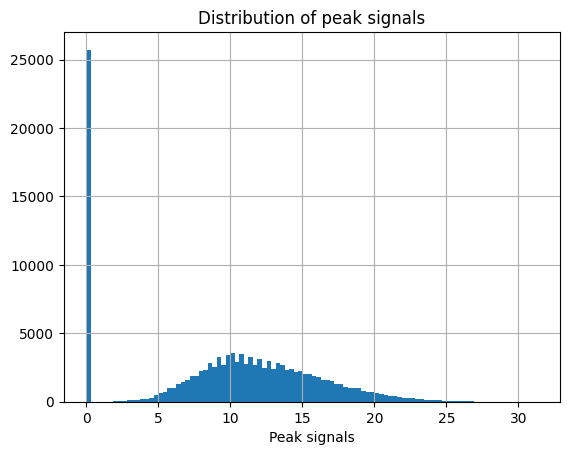

In [17]:
#The distribution of peak signals
df[3].hist(bins=100)
plt.xlabel("Peak signals")
plt.title("Distribution of peak signals")

In [ ]:
#Use chrom4 as the test data
chr4=df[0].str.split(':').str.get(0).isin(["chr4","rev_chr4"])
df_train=df[~chr4].reset_index()
df_test=df[chr4].reset_index()
#test data ratio
print(len(df[chr4])/len(df))

#df_20
X_DNA_train=encode_DNA(df_train[1])
y_train=np.array(df_train[2])

X_DNA_test=encode_DNA(df_test[1])
y_test=np.array(df_test[2])

X_DNA_train=X_DNA_train.swapaxes(1, 2)
X_DNA_test=X_DNA_test.swapaxes(1, 2)

In [18]:
#RNA only
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

def create_model():
    #Process input as tensor
    Dinput = Input(shape=(1000,4))
    
    encode_d= Conv1D(input_shape=(1000,4),
                            padding="valid",
                            strides=1,
                            activation="relu",
                            kernel_size=15,
                            filters=300,
                            use_bias=True)(Dinput)    
    #DNA subnetwork
    for i in range(1):
        encode_d= Conv1D(
                                padding="valid",
                                strides=1,
                                activation="relu",
                                kernel_size=9,
                                filters=200,
                                use_bias=True)(encode_d)
    encode_d = MaxPooling1D()(encode_d)
    encode_d = Dropout(0.2)(encode_d)

    encode_d=Flatten()(encode_d)

    FC_DNA = Dense(200, activation='relu')(encode_d)

    # Dense layers
    FC1 = Dense(256, activation='relu')(FC_DNA)
    FC1 = Dropout(0.2)(FC1)
    FC2 = Dense(256, activation='relu')(FC1)

    predictions = Dense(1, kernel_initializer='normal')(FC2) 
    
    combinedModel = Model(inputs=[Dinput], outputs=[predictions])
    combinedModel.compile(optimizer="adam", loss='mean_squared_error', metrics=['mean_squared_error'])
    
    print(combinedModel.summary())
    
    return combinedModel

Num GPUs Available:  1


In [46]:
#GRU
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

def create_model():
    #Process input as tensor
    Dinput = Input(shape=(226,4))
   

    encode_d= GRU( units=1000,activation="relu",recurrent_activation="relu", dropout=0.8,recurrent_dropout=0.8)(Dinput)
 
    
    #encode_d= GRU( units=256,activation="relu",recurrent_activation="relu", dropout=0.1,recurrent_dropout=0.1)(encode_d)
        


    #FC_DNA = Dense(200, activation='relu')(encode_d)

    # Dense layers
    FC1 = Dense(50, activation='relu')(encode_d)
    #FC1 = Dropout(0.2)(FC1)

    predictions = Dense(1, kernel_initializer='normal')(FC1) 
    
    combinedModel = Model(inputs=[Dinput], outputs=[predictions])
    
    op=keras.optimizers.Adam( clipnorm=0.0001,clipvalue=0.05) 
    combinedModel.compile(optimizer=op, loss='mean_squared_error', metrics=['mean_squared_error'])
    
    print(combinedModel.summary())

    return combinedModel

Num GPUs Available:  1


In [62]:
#RNA only
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

def create_model():
    #Process input as tensor
    Dinput = Input(shape=(500,4))
    
    encode_d= Conv1D(input_shape=(226,4),
                            padding="valid",
                            strides=1,
                            activation="relu",
                            kernel_size=3,
                            filters=500,
                            use_bias=True)(Dinput)    
    #DNA subnetwork
    for i in range(0):
        encode_d= Conv1D(
                                padding="valid",
                                strides=1,
                                activation="relu",
                                kernel_size=3,
                                filters=400,
                                use_bias=True)(encode_d)
    encode_d = MaxPooling1D()(encode_d)
    encode_d = Dropout(0.8)(encode_d)

    encode_d=Flatten()(encode_d)

    FC_DNA = Dense(400, activation='relu')(encode_d)

    # Dense layers
    FC1 = Dense(256, activation='relu')(FC_DNA)
    FC1 = Dropout(0.2)(FC1)
    FC2 = Dense(256, activation='relu')(FC1)

    predictions = Dense(1, kernel_initializer='normal')(FC2) 
    op=keras.optimizers.Adam(learning_rate=0.0001) 
    combinedModel = Model(inputs=[Dinput], outputs=[predictions])
    combinedModel.compile(optimizer=op, loss='mean_squared_error', metrics=['mean_squared_error'])
    
    print(combinedModel.summary())
    
    return combinedModel

Num GPUs Available:  1


In [19]:
checkpoint_path ="./training_checkpoints/"
checkpoint_dir = os.path.dirname(checkpoint_path)

earlystopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min')
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1)

combinedModel=create_model()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1000, 4)]         0         
                                                                 
 conv1d (Conv1D)             (None, 986, 300)          18300     
                                                                 
 conv1d_1 (Conv1D)           (None, 978, 200)          540200    
                                                                 
 max_pooling1d (MaxPooling1D  (None, 489, 200)         0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 489, 200)          0         
                                                                 
 flatten (Flatten)           (None, 97800)             0         
                                                             

2022-11-29 22:59:58.658192: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-11-29 22:59:58.658981: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-29 22:59:58.659265: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-29 22:59:58.659489: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

In [25]:
np.array(y_train)

array([12.25296, 17.06865, 17.16937, ...,  0.     ,  0.     , 10.31997])

In [26]:
combinedModel.fit(x=X_DNA_train,
                  y=np.array(y_train),epochs=50,
                  batch_size=128,
                  validation_split=0.05, 
                  callbacks=[model_checkpoint_callback])

Epoch 1/50


2022-11-29 23:02:29.412516: I tensorflow/stream_executor/cuda/cuda_dnn.cc:366] Loaded cuDNN version 8201
2022-11-29 23:02:29.942269: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-11-29 23:02:29.942796: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-11-29 23:02:29.942806: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2022-11-29 23:02:29.943230: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-11-29 23:02:29.943260: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2022-11-29 23:02:30.421341: I tensorflow/stream_executor/cuda/c

859/859 [==============================] - ETA: 0s - loss: 34.9807 - mean_squared_error: 34.9807
Epoch 00001: val_loss improved from inf to 28.42632, saving model to ./training_checkpoints/
859/859 [==============================] - 23s 24ms/step - loss: 34.9807 - mean_squared_error: 34.9807 - val_loss: 28.4263 - val_mean_squared_error: 28.4263
Epoch 2/50
858/859 [============================>.] - ETA: 0s - loss: 17.5362 - mean_squared_error: 17.5362
Epoch 00002: val_loss improved from 28.42632 to 14.29916, saving model to ./training_checkpoints/
859/859 [==============================] - 20s 24ms/step - loss: 17.5364 - mean_squared_error: 17.5364 - val_loss: 14.2992 - val_mean_squared_error: 14.2992
Epoch 3/50
857/859 [============================>.] - ETA: 0s - loss: 15.0147 - mean_squared_error: 15.0147
Epoch 00003: val_loss did not improve from 14.29916
859/859 [==============================] - 20s 23ms/step - loss: 15.0160 - mean_squared_error: 15.0160 - val_loss: 14.5798 - val_m

KeyboardInterrupt: 

In [20]:
combinedModel.fit(x=X_DNA_train,
                  y=y_train,epochs=50,
                  batch_size=128,
                  validation_split=0.05, 
                  callbacks=[model_checkpoint_callback])

ValueError: `validation_split` is only supported for Tensors or NumPy arrays, found following types in the input: [<class 'pandas.core.series.Series'>]

In [42]:
combinedModel.save("ucla3_r227_002.h5")

In [316]:
#load_model
combinedModel = keras.models.load_model("./models/ucla3/ucla3_711_r62.h5")

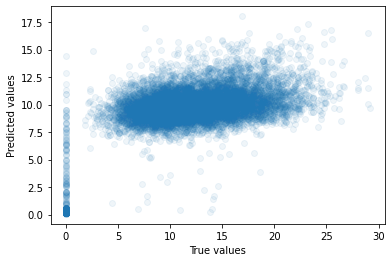

0.5446143284864183


In [332]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

#Predicting
Y_pred = combinedModel.predict([X_DNA_test])

#Plot
plt.scatter(y_test, Y_pred, alpha = 0.07)
#plt.plot(df_20['log Translation mitigation'], Y_pred)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

#R2 score
print(r2_score(y_test,Y_pred))

In [80]:
print(r2_score(y_train,combinedModel.predict([X_DNA_train])))

-0.3001959802453078


## Test variants with trained models

In [90]:
pd.read_csv("barcodes16-1.txt",header=None)

,0
0,AACAACAACAACAACC
1,AACAACAACAACAGGT
2,AACAACAACAACCGCA
3,AACAACAACAAGACGA
4,AACAACAACAAGCTCC
...,...
1636413,TTGTTGTTGGAAGGTC
1636414,TTGTTGTTGGACCTTA
1636415,TTGTTGTTGGTATGTG
1636416,TTGTTGTTGTACCACT


In [91]:
df

,0,1,2,3
0,40839,background_seq_40840,CAACCTTATAATTGTAATCAGTGATGAGAGCATTCTCTGGGTTTGA...,0.00000
1,63925,rev_background_seq_12495,TCCTCCGCGACGGTCGGCGCCGCGGGGCAGCCGGAGCTGAACGGGG...,0.00000
2,89770,rev_background_seq_38340,TTTCTCTAAAATACAATAGAGTCAGTTCAATTTGCACACCAGAAAC...,0.00000
3,80357,rev_background_seq_28927,TAATTGTCAGATTCTTGATTGGTTCGTTCCTCAGACAACACTTCTA...,0.00000
4,7780,background_seq_7781,CTTTGAATTGCCGGCCGTGTCAGTGCCAAATTTTCAGGCAGTCATG...,0.00000
...,...,...,...,...
205719,102857,chr20:39657662-39657888,CCCACGCCGCCTCGCCTGCCGCCGCGCTCGTCCCTCCGGGCCGACA...,1.92644
205720,102858,chr1:151210861-151211087,GCTACTTACTTCATTAGTTTTCAGATGGTTTATTTCCTTGATTTTG...,2.20994
205721,102859,chr10:27418987-27419213,TAAACCCACTGCAATTGGAATTTAACCCCTGCTACTCCACTAACAT...,2.20994
205722,102860,chr2:69001534-69001760,AAAACAAAAGCCAAATATACCATGCTGAGTGCATGCAGGTTCAAGG...,2.06186


In [ ]:
>chr20:54987102-54987329
AGGACAAGAATGCTGTGTGTTCATACACTGAGCTCTTCGAAGTAGGAACTTCGCCCTATAAAGCAGAAGAGTGGTGTTTTTTTCTTCTTCTTCTTCTTTTGTGGTTTCACATAGCAAATGAGTGACAGTCTCTACTTACAGACAAAGTGAGACGTCAGGCATTGAGACGTGAGTGTGGCTTGTATTTCTGGTCCTCCCCTGCTTCACTGCTTTCATTTTACTCTTAT
>chr6:32577670-32577897
CTAGGCATTTCAAGAAAGAAAAGCATTCCTGGAAATCCCCAATCGGTCACAGGCATGTTTCTCCAACCAATAGGAATAGAGAATGAGGCAGCATCACTTGTCTCCAGCAGATACATCTGCTAAGAAGGTCTGATCTGATCCCAGGTCTTGGGGAGGAGGCAGGGAAGGAGCAGGATGACTCATGAGTGGTGAGAAGAATGGCTGACGATGTAGTTTCATGGAAAGAA
>chr6:32577671-32577898
TAGGCATTTCAAGAAAGAAAAGCATTCCTGGAAATCCCCAATCGGTCACAGGCATGTTTCTCCAACCAATAGGAATAGAGAATGAGGCAGCATCACTTGTCTCCAGCAGATACATCTGCTAAGAAGGTCTGATCTGATCCCAGGTCTTGGGGAGGAGGCAGGGAAGGAGCAGGATGACTCATGAGTGGTGAGAAGAATGGCTGACGATGTAGTTTCATGGAAAGAAA

In [197]:
enhancer[112:115]

'GCA'

In [277]:
barcode = "TTGTTGTTGGACCTTA"
left_flank = "TGGGCTGGGAGGCCTCCTCCGAGCGGATGTACCCCGAGGACGGCGCCCTGAAGGGCGAGATCAAGCAGAGGCTGAAGCTGAAGGACGGCGGCCACTACGACGCTGAGGTCAAGACCACCTACAAGGCCAAGAAGCCCGTGCAGCTGCCCGGCGCCTACAACGTCAACATCAAGTTGGACATCACCTCCCACAACGAGGACTACACCATCGTGGAACAGTACGAACGCGCCGAGGGCCGCCACTCCACCGGCGGCATGGACGAGCTGTACAAGggaagccccaagaaaaagcggaaggtgtaaGTCTCGTGGGCTCGGAGATGTGTATAAGAGACAGggatccACggcGCGCCAAATGGAGAAAcatggAgtctgaAcCTGtGtGCta"
right_flank = "GGTACCTCTAGA{}TCAGAAGATCGGAAGAGCaTCgtAGTGGTACCTAGCATCTCACCCCTGTCTCTTATACACATCTGACGCTGCCGACGATCTAATTTAATATATTGATATTTATATCATTTTACGTTTCTCGTTCAGCTTTCTTGTACAAAGTGGTTGGCCTCGGCGGCCGCGCTTCGAGCttcgagcagacatgataagatacattgatgagtttggacaaaccacaactagaatgcagtgaaaaaaatgctttatttgtgaaatttgtgatgctattgctttatttgtaaccattataagctgcaataaacaagttaacaacaacaattgcattcattttatgtttcaggttcagggggagatgtgg".format(barcode)
#enhancer = "caacatggcaaaaccccgtctctactaaaaatgcaaaaattagctgggca tggtagtatgtgcctgtaatcccagatacttgggtggctgaggcatgaga atcacttcaaccctggaggtggaagttgcagtgagctgagatcacaccac tgtactccagcctgggtgacagagcaagactctgtctcaaaagagagaga gggagagagagagagagagagagagag"
#enhancer = "cgctcgcgtgcgagagaagcgaccttaacgaagatgaagccaggagaccacgggatgcacaaaataagggaagttagcagcttgagaactccgaccgggtcagcctgtccgacaacaggcgagtataattggcaagcttttgaaaaaggcaagagataatgggagggattgaatggccggcggtcgcaagagctttttgatatcaatatagcataaatagtcgcact"
enhancer = "TAGGCATTTCAAGAAAGAAAAGCATTCCTGGAAATCCCCAATCGGTCACAGGCATGTTTCTCCAACCAATAGGAATAGAGAATGAGGCAGCATCACTTGTCTCCAGCAGATACATCTGCTAAGAAGGTCTGATCTGATCCCAGGTCTTGGGGAGGAGGCAGGGAAGGAGCAGGATGACTCATGAGTGGTGAGAAGAATGGCTGACGATGTAGTTTCATGGAAAGAAA"
#enhancer='AGGACAAGAATGCTGTGTGTTCATACACTGAGCTCTTCGAAGTAGGAACTTCGCCCTATAAAGCAGAAGAGTGGTGTTTTTTTCTTCTTCTTCTTCTTTTGTGGTTTCACATA'+"C"+'CAAATGAGTGACAGTCTCTACTTACAGACAAAGTGAGACGTCAGGCATTGAGACGTGAGTGTGGCTTGTATTTCTGGTCCTCCCCTGCTTCACTGCTTTCATTTTACTCTTAT'
enhancer=enhancer.replace(" ","")

SNP = "TG"
variant = enhancer[:112]+SNP+enhancer[114:227]

test_variant = left_flank + variant  + right_flank
test_variant = str.upper(test_variant)
test_variant

'TGGGCTGGGAGGCCTCCTCCGAGCGGATGTACCCCGAGGACGGCGCCCTGAAGGGCGAGATCAAGCAGAGGCTGAAGCTGAAGGACGGCGGCCACTACGACGCTGAGGTCAAGACCACCTACAAGGCCAAGAAGCCCGTGCAGCTGCCCGGCGCCTACAACGTCAACATCAAGTTGGACATCACCTCCCACAACGAGGACTACACCATCGTGGAACAGTACGAACGCGCCGAGGGCCGCCACTCCACCGGCGGCATGGACGAGCTGTACAAGGGAAGCCCCAAGAAAAAGCGGAAGGTGTAAGTCTCGTGGGCTCGGAGATGTGTATAAGAGACAGGGATCCACGGCGCGCCAAATGGAGAAACATGGAGTCTGAACCTGTGTGCTATAGGCATTTCAAGAAAGAAAAGCATTCCTGGAAATCCCCAATCGGTCACAGGCATGTTTCTCCAACCAATAGGAATAGAGAATGAGGCAGCATCACTTGTCTCCAGCAGATATGTCTGCTAAGAAGGTCTGATCTGATCCCAGGTCTTGGGGAGGAGGCAGGGAAGGAGCAGGATGACTCATGAGTGGTGAGAAGAATGGCTGACGATGTAGTTTCATGGAAAGAAAGGTACCTCTAGATTGTTGTTGGACCTTATCAGAAGATCGGAAGAGCATCGTAGTGGTACCTAGCATCTCACCCCTGTCTCTTATACACATCTGACGCTGCCGACGATCTAATTTAATATATTGATATTTATATCATTTTACGTTTCTCGTTCAGCTTTCTTGTACAAAGTGGTTGGCCTCGGCGGCCGCGCTTCGAGCTTCGAGCAGACATGATAAGATACATTGATGAGTTTGGACAAACCACAACTAGAATGCAGTGAAAAAAATGCTTTATTTGTGAAATTTGTGATGCTATTGCTTTATTTGTAACCATTATAAGCTGCAATAAACAAGTTAACAACAACAATTGCATTCATTTTATGTTTCAGGTTCAGGGGGAGATGTG

In [278]:
len(enhancer)

227

In [279]:
#load_model
combinedModel = keras.models.load_model("./models/ucla3/ucla3_711_r62.h5")

In [280]:
test_variant_onehot=encode_DNA(test_variant)
test_variant_onehot=test_variant_onehot.swapaxes(0, 1)
test_variant_onehot=test_variant_onehot.swapaxes(0, 2)

In [220]:
np.shape(test_variant_onehot)

(1, 1000, 4)

In [126]:
combinedModel.predict(test_variant_onehot)

array([[11.723791]], dtype=float32)

In [141]:
combinedModel.predict(test_variant_onehot)

array([[11.630205]], dtype=float32)

In [148]:
combinedModel.predict(test_variant_onehot)

array([[11.415712]], dtype=float32)

In [152]:
combinedModel.predict(test_variant_onehot)

array([[8.094586]], dtype=float32)

In [276]:
combinedModel.predict(test_variant_onehot)

array([[11.791351]], dtype=float32)

In [281]:
combinedModel.predict(test_variant_onehot)

array([[11.828514]], dtype=float32)

In [ ]:
X_DNA_train=encode_DNA(X_train.to_list())
X_DNA_test = encode_DNA(X_test.to_list())

X_DNA_train=X_DNA_train.swapaxes(1, 2)
X_DNA_test=X_DNA_test.swapaxes(1, 2)

# 2021.11.13 Peak centered inputs and authentic controls

In [7]:
df=pd.read_csv("UCLA3_XY_20211113.csv",header=None)
df

,0,1,2,3,4
0,chr9:136890121-136890621,CCCCTCCTCCCACCTCCGCTCCCAGCCCCTCCTCCTTTCCCAGCCC...,26.63848,GGGGAGGAGGGTGGAGGCGAGGGTCGGGGAGGAGGAAAGGGTCGGG...,1
1,chr3:99979424-99979924,CGCCTTCCCTATGTCAATTCCCATTTCCCTTGCTTTCTCCAATAGT...,21.78039,GCGGAAGGGATACAGTTAAGGGTAAAGGGAACGAAAGAGGTTATCA...,1
2,chr3:129830209-129830709,CGCCGCCCACCTGCCAGGGGAAGGAGCGCAGTGTGCGCGCCGCTAG...,28.28994,GCGGCGGGTGGACGGTCCCCTTCCTCGCGTCACACGCGCGGCGATC...,1
3,chr16:72042322-72042822,GTGTGAAACACAGTGTTTTGATGCTCGCGGACTCTTGGATTCGAGG...,28.88563,CACACTTTGTGTCACAAAACTACGAGCGCCTGAGAACCTAAGCTCC...,1
4,chr2:179315694-179316194,GAAGGTCCCACTGTCCTCGCGCTCCAGCGGCGGGGCCTCGGCGCGG...,17.30506,CTTCCAGGGTGACAGGAGCGCGAGGTCGCCGCCCCGGAGCCGCGCC...,1
...,...,...,...,...,...
148469,chr1_151431001,CAAAACGAGCGCCCCACTCCTTCTCGGAGCGGGAATGGGGCGGGGA...,0.00000,GTTTTGCTCGCGGGGTGAGGAAGAGCCTCGCCCTTACCCCGCCCCT...,0
148470,chr22_48971501,CGGAGGCGCGGGCTGCTGGGAGCGCAGAGGCCGGCACCGTCCGGTG...,0.00000,GCCTCCGCGCCCGACGACCCTCGCGTCTCCGGCCGTGGCAGGCCAC...,0
148471,chr17_78234001,GTCCACTGCACCCGCCGGGCGCCCTCTGGGCCGCTCCCAGGCTGGC...,0.00000,CAGGTGACGTGGGCGGCCCGCGGGAGACCCGGCGAGGGTCCGACCG...,0
148472,chr16_29817501,GGTAACAACTCCCTCCCCCCGCCCCCACCCCCCTGCCCACACCCCC...,0.00000,CCATTGTTGAGGGAGGGGGGCGGGGGTGGGGGGACGGGTGTGGGGG...,0


In [8]:

#Data process
X_AA=encode_DNA(df[1])
#X_AA = np.expand_dims(X_AA, axis=3)
X_DNA=encode_DNA(df[3])
#X_DNA = np.expand_dims(X_DNA, axis=3)

X_AA=X_AA.swapaxes(1, 2)
X_DNA=X_DNA.swapaxes(1, 2)

y=np.array(df[2])


X_AA_test=X_AA[0:7000]
X_DNA_test=X_DNA[0:7000]

y_test=y[0:7000]


X_DNA_train=X_DNA[7000:]
X_AA_train=X_AA[7000:]

y_train=y[7000:]


In [9]:
X_AA.shape

(148474, 500, 4)

In [83]:
#RNA + AA
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers

import numpy
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


#Process input as tensor
Dinput = Input(shape=(500,4))
Tinput = Input(shape=(500,4))


#DNA subnetwork
encode_d= Conv1D(padding="same",strides=1,activation="relu",kernel_size=5,filters=100,use_bias=True)(Dinput)    
encode_d= Conv1D(padding="same",strides=1,activation="relu",kernel_size=3,filters=100,use_bias=True)(encode_d)   
encode_d = MaxPooling1D()(encode_d)
encode_d = Dropout(0.2)(encode_d)
encode_d=Flatten()(encode_d)
FC_DNA = Dense(100, activation='relu')(encode_d)

#Amino acid subnetwork
encode_tt = Conv1D(padding="same",strides=1,activation="relu",kernel_size=5,filters=100,use_bias=True)(Tinput)
encode_tt = Conv1D(padding="same",strides=1,activation="relu",kernel_size=3,filters=100,use_bias=True)(encode_tt)
encode_tt = MaxPooling1D()(encode_tt)
encode_d = Dropout(0.2)(encode_tt)
encode_tt=Flatten()(encode_tt)
FC_AA = Dense(100, activation='relu')(encode_tt)

#Combine DNA and AA subnetworks
encode_combined = keras.layers.concatenate([FC_DNA, FC_AA])

# Dense layers
FC1 = Dense(128, activation='relu')(encode_combined)
FC1 = Dropout(0.5)(FC1)
FC2 = Dense(128, activation='relu')(FC1)

predictions = Dense(1, kernel_initializer='normal')(FC2) 
op=tf.keras.optimizers.Adam(learning_rate=0.0001) 
combinedModel = Model(inputs=[Dinput, Tinput], outputs=[predictions])
combinedModel.compile(optimizer=op, loss='mean_squared_error', metrics=['mean_squared_error'])

print(combinedModel.summary())


Num GPUs Available:  1
Model: "model_25"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_63 (InputLayer)           [(None, 500, 4)]     0                                            
__________________________________________________________________________________________________
conv1d_84 (Conv1D)              (None, 500, 100)     2100        input_63[0][0]                   
__________________________________________________________________________________________________
input_64 (InputLayer)           [(None, 500, 4)]     0                                            
__________________________________________________________________________________________________
conv1d_85 (Conv1D)              (None, 500, 100)     30100       conv1d_84[0][0]                  
____________________________________________________________________

In [79]:

#Training
combinedModel.fit(x=[X_DNA_train, X_AA_train],y=y_train,epochs=50,validation_split=0.05, batch_size=100)

#Predicting
Y_pred_test = combinedModel.predict([X_DNA_test, X_AA_test])
Y_pred_train = combinedModel.predict([X_DNA_train, X_AA_train])

#Plot
plt.scatter(Y_pred_test,y_test)
plt.title("Test set")
plt.show()
#R2 score
print("Test set R2:",r2_score(Y_pred_test,y_test))

#Plot
plt.scatter(Y_pred_train, y_train)
plt.title("Training set")
plt.show()
#R2 score
print("Training set R2:",r2_score(Y_pred_train,y_train))



Epoch 1/50


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [75]:
X_AA.shape

(148474, 4, 500)

In [38]:
df = df.sample(frac=1).reset_index(drop=True)
#Data process
X_AA=encode_DNA(df[1])
#X_AA = np.expand_dims(X_AA, axis=3)
X_DNA=encode_DNA(df[3])
#X_DNA = np.expand_dims(X_DNA, axis=3)

X_AA=X_AA.swapaxes(1, 2)
X_DNA=X_DNA.swapaxes(1, 2)

y=np.array(df[4])


X_AA_test=X_AA[0:7000]
X_DNA_test=X_DNA[0:7000]

y_test=y[0:7000]


X_DNA_train=X_DNA[7000:]
X_AA_train=X_AA[7000:]

y_train=y[7000:]


In [37]:
#RNA + AA
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
#from keras.layers import Dense, Dropout, Flatten, Input,Activation,MaxPooling2D, GRU,LSTM, MaxPooling1D
#from keras.layers import Convolution2D as Conv2D
#from keras.layers import Convolution1D as Conv1D
import numpy
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


#Process input as tensor
Dinput = Input(shape=(500,4))
Tinput = Input(shape=(500,4))


#forward sequences
encode_d= Conv1D(padding="valid",strides=1,activation="relu",kernel_size=10,filters=100,use_bias=True)(Dinput)
encode_d = MaxPooling1D()(encode_d)
encode_d = Dropout(0.2)(encode_d)
encode_d= Conv1D(padding="valid",strides=1,activation="relu",kernel_size=3,filters=100,use_bias=True)(encode_d)   
encode_d = MaxPooling1D()(encode_d)
encode_d = Dropout(0.2)(encode_d)
encode_d=Flatten()(encode_d)
#FC_DNA = Dense(100, activation='relu')(encode_d)

#reverse complementry subnetwork
encode_tt = Conv1D(padding="valid",strides=1,activation="relu",kernel_size=10,filters=100,use_bias=True)(Tinput)
encode_tt = MaxPooling1D()(encode_tt)
encode_tt = Dropout(0.2)(encode_tt)
encode_tt = Conv1D(padding="valid",strides=1,activation="relu",kernel_size=3,filters=100,use_bias=True)(encode_tt)
encode_tt = MaxPooling1D()(encode_tt)
encode_tt = Dropout(0.2)(encode_tt)
encode_tt=Flatten()(encode_tt)
#FC_AA = Dense(100, activation='relu')(encode_tt)

#Combine DNA and AA subnetworks
#encode_combined =layers.concatenate([FC_DNA, FC_AA])
encode_combined =layers.concatenate([encode_d,encode_tt])
# Dense layers
FC1 = Dense(128, activation='sigmoid')(encode_combined)
FC1 = Dropout(0.5)(FC1)
#FC2 = Dense(128, activation='sigmoid')(FC1)

predictions = Dense(1, kernel_initializer='normal')(FC1) 
#op=tf.keras.optimizers.Adam(learning_rate=0.00001) 
combinedModel = Model(inputs=[Dinput, Tinput], outputs=[predictions])
combinedModel.compile(loss='binary_crossentropy', optimizer="rmsprop", metrics=['accuracy'])

print(combinedModel.summary())


Num GPUs Available:  1
Model: "model_6"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_13 (InputLayer)           [(None, 500, 4)]     0                                            
__________________________________________________________________________________________________
input_14 (InputLayer)           [(None, 500, 4)]     0                                            
__________________________________________________________________________________________________
conv1d_24 (Conv1D)              (None, 491, 100)     4100        input_13[0][0]                   
__________________________________________________________________________________________________
conv1d_26 (Conv1D)              (None, 491, 100)     4100        input_14[0][0]                   
_____________________________________________________________________

In [46]:

#Training
combinedModel.fit(x=[X_DNA_train, X_AA_train],y=y_train,epochs=50,validation_split=0.05, batch_size=8000)

#Predicting
#Y_pred_test = combinedModel.predict([X_DNA_test, X_AA_test])
#Y_pred_train = combinedModel.predict([X_DNA_train, X_AA_train])




Epoch 1/50
17/17 [==============================] - 7s 432ms/step - loss: 0.3873 - accuracy: 0.8432 - val_loss: 0.3569 - val_accuracy: 0.8543
Epoch 2/50
17/17 [==============================] - 7s 426ms/step - loss: 0.4316 - accuracy: 0.8301 - val_loss: 0.3713 - val_accuracy: 0.8534
Epoch 3/50
17/17 [==============================] - 7s 427ms/step - loss: 0.3945 - accuracy: 0.8394 - val_loss: 0.3699 - val_accuracy: 0.8478
Epoch 4/50
17/17 [==============================] - 7s 429ms/step - loss: 0.4036 - accuracy: 0.8390 - val_loss: 0.4064 - val_accuracy: 0.8141
Epoch 5/50
17/17 [==============================] - 7s 429ms/step - loss: 0.4035 - accuracy: 0.8369 - val_loss: 0.3683 - val_accuracy: 0.8466
Epoch 6/50
17/17 [==============================] - 7s 430ms/step - loss: 0.4200 - accuracy: 0.8344 - val_loss: 0.4520 - val_accuracy: 0.7822
Epoch 7/50
17/17 [==============================] - 7s 431ms/step - loss: 0.3955 - accuracy: 0.8368 - val_loss: 0.3597 - val_accuracy: 0.8554
Epoch 

In [42]:
combinedModel.save("ucla3_classification0.83.h5")

In [49]:
df = df.sample(frac=1).reset_index(drop=True)
#Data process
X_AA=encode_DNA(df[1])
#X_AA = np.expand_dims(X_AA, axis=3)
X_DNA=encode_DNA(df[3])
#X_DNA = np.expand_dims(X_DNA, axis=3)

X_AA=X_AA.swapaxes(1, 2)
X_DNA=X_DNA.swapaxes(1, 2)

y=np.array(df[2])


X_AA_test=X_AA[0:7000]
X_DNA_test=X_DNA[0:7000]

y_test=y[0:7000]


X_DNA_train=X_DNA[7000:]
X_AA_train=X_AA[7000:]

y_train=y[7000:]


In [58]:
#RNA + AA
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
#from keras.layers import Dense, Dropout, Flatten, Input,Activation,MaxPooling2D, GRU,LSTM, MaxPooling1D
#from keras.layers import Convolution2D as Conv2D
#from keras.layers import Convolution1D as Conv1D
import numpy
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


#Process input as tensor
Dinput = Input(shape=(500,4))
Tinput = Input(shape=(500,4))


#forward sequences
encode_d= Conv1D(padding="valid",strides=1,activation="relu",kernel_size=10,filters=100,use_bias=True)(Dinput)
encode_d = MaxPooling1D()(encode_d)
encode_d = Dropout(0.2)(encode_d)
encode_d= Conv1D(padding="valid",strides=1,activation="relu",kernel_size=3,filters=100,use_bias=True)(encode_d)   
encode_d = MaxPooling1D()(encode_d)
encode_d = Dropout(0.2)(encode_d)
encode_d=Flatten()(encode_d)
#FC_DNA = Dense(100, activation='relu')(encode_d)

#reverse complementry subnetwork
encode_tt = Conv1D(padding="valid",strides=1,activation="relu",kernel_size=10,filters=100,use_bias=True)(Tinput)
encode_tt = MaxPooling1D()(encode_tt)
encode_tt = Dropout(0.2)(encode_tt)
encode_tt = Conv1D(padding="valid",strides=1,activation="relu",kernel_size=3,filters=100,use_bias=True)(encode_tt)
encode_tt = MaxPooling1D()(encode_tt)
encode_tt = Dropout(0.2)(encode_tt)
encode_tt=Flatten()(encode_tt)
#FC_AA = Dense(100, activation='relu')(encode_tt)

#Combine DNA and AA subnetworks
#encode_combined =layers.concatenate([FC_DNA, FC_AA])
encode_combined =layers.concatenate([encode_d,encode_tt])
# Dense layers
FC1 = Dense(128, activation='relu')(encode_combined)
FC1 = Dropout(0.5)(FC1)
#FC2 = Dense(128, activation='sigmoid')(FC1)

predictions = Dense(1, kernel_initializer='normal')(FC1) 
op=tf.keras.optimizers.Adam(learning_rate=0.000001) 
combinedModel = Model(inputs=[Dinput, Tinput], outputs=[predictions])
combinedModel.compile(optimizer="adam", loss='mean_squared_error', metrics=['mean_squared_error'])

print(combinedModel.summary())


Num GPUs Available:  1
Model: "model_12"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_25 (InputLayer)           [(None, 500, 4)]     0                                            
__________________________________________________________________________________________________
input_26 (InputLayer)           [(None, 500, 4)]     0                                            
__________________________________________________________________________________________________
conv1d_48 (Conv1D)              (None, 491, 100)     4100        input_25[0][0]                   
__________________________________________________________________________________________________
conv1d_50 (Conv1D)              (None, 491, 100)     4100        input_26[0][0]                   
____________________________________________________________________

In [61]:

#Training
combinedModel.fit(x=[X_DNA_train, X_AA_train],y=y_train,epochs=50,validation_split=0.05, batch_size=500)

#Predicting
Y_pred_test = combinedModel.predict([X_DNA_test, X_AA_test])
Y_pred_train = combinedModel.predict([X_DNA_train, X_AA_train])



Epoch 1/50
269/269 [==============================] - 9s 31ms/step - loss: 18.7862 - mean_squared_error: 18.7862 - val_loss: 21.8412 - val_mean_squared_error: 21.8412
Epoch 2/50
269/269 [==============================] - 8s 31ms/step - loss: 17.9508 - mean_squared_error: 17.9508 - val_loss: 22.7304 - val_mean_squared_error: 22.7304
Epoch 3/50
269/269 [==============================] - 8s 31ms/step - loss: 17.5400 - mean_squared_error: 17.5400 - val_loss: 19.5970 - val_mean_squared_error: 19.5970
Epoch 4/50
269/269 [==============================] - 8s 31ms/step - loss: 17.1384 - mean_squared_error: 17.1384 - val_loss: 20.5324 - val_mean_squared_error: 20.5324
Epoch 5/50
269/269 [==============================] - 8s 31ms/step - loss: 16.5221 - mean_squared_error: 16.5221 - val_loss: 20.2920 - val_mean_squared_error: 20.2920
Epoch 6/50
269/269 [==============================] - 8s 31ms/step - loss: 16.4153 - mean_squared_error: 16.4153 - val_loss: 21.2098 - val_mean_squared_error: 21.209

Epoch 50/50
269/269 [==============================] - 8s 31ms/step - loss: 11.1307 - mean_squared_error: 11.1307 - val_loss: 21.6499 - val_mean_squared_error: 21.6499


In [ ]:
#Plot
plt.scatter(Y_pred_test,y_test)
plt.title("Test set")
plt.show()
#R2 score
print("Test set R2:",r2_score(Y_pred_test,y_test))

#Plot
plt.scatter(Y_pred_train, y_train)
plt.title("Training set")
plt.show()
#R2 score
print("Training set R2:",r2_score(Y_pred_train,y_train))

